# Datos, análisis exploratorio y construcción de la etiqueta

**Conjunto de datos.** COFINFAD (*Colombian Fintech Financial Analytics Dataset*), publicado en
Mendeley Data (DOI 10.17632/mhb4zn3258.1, licencia CC BY 4.0): clientes de una *fintech* colombiana
en 2023, en dos archivos. `customer_data.csv` tiene un registro por cliente (perfil demográfico,
tenencia de productos, uso digital, satisfacción, resúmenes transaccionales y las variables
objetivo) y `transactions_data.csv`, el detalle de cada transacción.

**Problema.** Anticipar la fuga de clientes en dos formulaciones: **regresión** sobre
`churn_probability` y **clasificación** de *riesgo alto*, el cuarto superior de esa probabilidad.

**Orden de esta sección.** El profesor señaló en la Entrega 1 que no había ninguna partición
entrenamiento/prueba en el cuaderno, justo cuando el trabajo dependía de evitar fugas de
información: los estadísticos del objetivo se habían calculado con todos los clientes. Aquí el
flujo está fijado en código (`src/datos.py`) y en este orden: se cargan y auditan las tablas, se
derivan las variables transaccionales (ninguna usa el objetivo), **se parte antes de mirar el
objetivo**, y todo estadístico que involucra el objetivo se calcula solo con el entrenamiento. La
función de diagnóstico recibe la partición y lo impone por sí misma.

In [1]:
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from src import datos, graficos
from src.config import SEED, TEST_SIZE
from src.formato import dec, ent, enumerar, pct

graficos.estilo()
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

p = datos.preparar_todo()          # carga → auditoría → variables derivadas → partición → diagnósticos → etiqueta
clientes, tx, df = p['clientes'], p['tx'], p['df']
particion, diag, etiqueta = p['particion'], p['diagnosticos'], p['etiqueta']
entrenamiento = df.loc[particion.idx_train]
objetivo = entrenamiento['churn_probability']
print(f'clientes: {clientes.shape[0]:,} × {clientes.shape[1]} · transacciones tras limpiar: {len(tx):,}')

clientes: 48,723 × 54 · transacciones tras limpiar: 3,159,055


## 1. Carga, auditoría y variables derivadas

In [2]:
aud = p['auditoria']
auditoria = pd.Series({'transacciones en el archivo': len(tx) + aud['duplicadas'],
                       'filas exactamente duplicadas (eliminadas)': aud['duplicadas'],
                       'montos no positivos': aud['montos_no_positivos'], 'fechas nulas': aud['fechas_nulas'],
                       'transacciones sin cliente': aud['huerfanas'], 'clientes sin transacciones': aud['clientes_sin_tx']})
display(auditoria.to_frame('recuento'))
derivadas = datos.columnas_transaccionales(df)
display(Markdown(f"""
Las dos tablas son consistentes: no hay montos inválidos, fechas nulas ni transacciones sin cliente,
y todos los clientes tienen actividad. Se eliminaron {ent(aud['duplicadas'])} transacciones exactamente
duplicadas. Del detalle se derivan {len(derivadas)} variables de comportamiento por cliente
({enumerar(f'`{v}`' for v in derivadas)}); ninguna usa el objetivo, así que pueden calcularse sobre todos
los clientes sin fuga. La tabla unida tiene {ent(df.shape[0])} clientes y {df.shape[1]} columnas.
"""))

,recuento
transacciones en el archivo,3159157
filas exactamente duplicadas (eliminadas),102
montos no positivos,0
fechas nulas,0
transacciones sin cliente,0
clientes sin transacciones,0



Las dos tablas son consistentes: no hay montos inválidos, fechas nulas ni transacciones sin cliente,
y todos los clientes tienen actividad. Se eliminaron 102 transacciones exactamente
duplicadas. Del detalle se derivan 12 variables de comportamiento por cliente
(`n_tx`, `monto_total`, `monto_medio`, `monto_mediano`, `recencia_dias`, `dias_activo`, `volatilidad_monto`, `meses_activos`, `prop_Deposit`, `prop_Payment`, `prop_Transfer` y `prop_Withdrawal`); ninguna usa el objetivo, así que pueden calcularse sobre todos
los clientes sin fuga. La tabla unida tiene 48.723 clientes y 66 columnas.


## 2. Partición antes de mirar el objetivo

In [3]:
n_tr, n_te = len(particion.idx_train), len(particion.idx_test)
display(pd.DataFrame({'clientes': [n_tr, n_te], 'fracción': [n_tr / len(df), n_te / len(df)]},
                     index=['entrenamiento', 'prueba']))
display(Markdown(f"""
La partición es 80/20 con la semilla {SEED}, la misma de la Entrega 2 (así la comparación con ella usa
exactamente los mismos clientes de prueba). Se hace sobre los índices, **sin estratificar**, porque la
etiqueta todavía no existe: su umbral se estimará después y solo con entrenamiento. La prueba
({ent(n_te)} clientes) no se vuelve a tocar hasta la evaluación final de cada modelo. Los
diagnósticos que siguen indican en qué conjunto se calcularon: los que involucran el objetivo, en
entrenamiento ({ent(diag['n_train'])} clientes); los puramente estructurales (columnas duplicadas,
faltantes), en la tabla completa, porque no usan el objetivo.
"""))

,clientes,fracción
entrenamiento,38978,0.8000
prueba,9745,0.2000



La partición es 80/20 con la semilla 42, la misma de la Entrega 2 (así la comparación con ella usa
exactamente los mismos clientes de prueba). Se hace sobre los índices, **sin estratificar**, porque la
etiqueta todavía no existe: su umbral se estimará después y solo con entrenamiento. La prueba
(9.745 clientes) no se vuelve a tocar hasta la evaluación final de cada modelo. Los
diagnósticos que siguen indican en qué conjunto se calcularon: los que involucran el objetivo, en
entrenamiento (38.978 clientes); los puramente estructurales (columnas duplicadas,
faltantes), en la tabla completa, porque no usan el objetivo.


## 3. El objetivo y la etiqueta

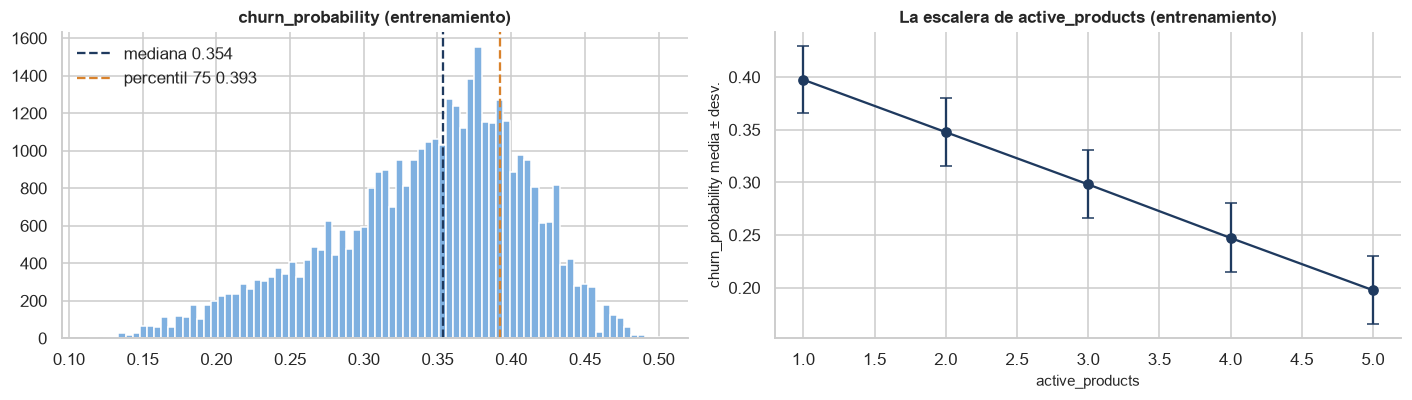

,count,mean,std,salto
active_products,,,,
1,15658,0.3975,0.0321,NaN
2,11714,0.3477,0.0326,-0.0498
3,5807,0.2981,0.0322,-0.0496
4,3855,0.2473,0.0328,-0.0508
5,1944,0.1977,0.0324,-0.0496


In [4]:
umbral_p75 = etiqueta.umbral
umbral_med = float(objetivo.median())
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].hist(objetivo, bins=80, color='#7fb0e0', edgecolor='white')
ax[0].axvline(umbral_med, color=graficos.AZUL, ls='--', label=f'mediana {umbral_med:.3f}')
ax[0].axvline(umbral_p75, color='#d9822b', ls='--', label=f'percentil 75 {umbral_p75:.3f}')
ax[0].set_title('churn_probability (entrenamiento)')
ax[0].legend(frameon=False)
escalera = diag['escalera']
ax[1].errorbar(escalera.index, escalera['mean'], yerr=escalera['std'], marker='o', color=graficos.AZUL, capsize=4)
ax[1].set_xlabel('active_products')
ax[1].set_ylabel('churn_probability media ± desv.')
ax[1].set_title('La escalera de active_products (entrenamiento)')
plt.tight_layout()
plt.show()
display(escalera)

In [5]:
display(Markdown(f"""
**`churn_probability` no es un evento observado sino un puntaje.** Toma valores entre
{dec(objetivo.min(), 3)} y {dec(objetivo.max(), 3)}, nunca 0 ni 1, y según la ficha del conjunto es la salida de un
modelo con ventana de 30 días. Su relación con `active_products` lo confirma: la correlación es
{dec(diag['r_active_products'], 3, True)} (esa sola variable explica el {pct(diag['r2_active_products'], 1)} de la varianza), y la media
desciende en una escalera de saltos casi idénticos ({enumerar(dec(s, 4, True) for s in escalera['salto'].dropna())};
desviación entre saltos {dec(diag['desv_saltos'], 5)}) con la misma dispersión en cada nivel. Un paso
constante es la firma de una regla de generación, no de una asociación empírica. Las variables de
tenencia de productos no la reconstruyen (su suma coincide con `active_products` en el
{pct(diag['booleanas_vs_active']['coincidencia_pct'] / 100, 1)} de los clientes; r = {dec(diag['booleanas_vs_active']['r'], 3)}), así que se conservan.

**Decisión: `active_products` se excluye como predictor.** Con ella el problema sería recuperar la
fórmula de la etiqueta, no predecir la fuga: un modelo que la conoce explica el 99,9 % del objetivo
(sección del modelo nuevo). Excluirla deja el problema con su dificultad real.

**La etiqueta.** *Riesgo alto* es el cuarto superior de `churn_probability`: el umbral es el percentil
75 **del entrenamiento** ({dec(umbral_p75, 4)}), fijo para entrenamiento y prueba, y deja un
{pct(p['y_train'].mean(), 1)} de positivos en entrenamiento y un {pct(p['y_test'].mean(), 1)} en prueba. Se prefirió al de la
mediana ({dec(umbral_med, 4)}), que usó la Entrega 2, porque la mediana deja las clases al 50 % por
construcción y vacía de sentido la etapa de balanceo: ADASYN no puede generar ningún cliente y
SMOTE añade unos pocos. La comparación con la Entrega 2 se hace con la etiqueta de la mediana, para
que las cifras sean comparables.
"""))


**`churn_probability` no es un evento observado sino un puntaje.** Toma valores entre
0,114 y 0,501, nunca 0 ni 1, y según la ficha del conjunto es la salida de un
modelo con ventana de 30 días. Su relación con `active_products` lo confirma: la correlación es
−0,876 (esa sola variable explica el 76,8 % de la varianza), y la media
desciende en una escalera de saltos casi idénticos (−0,0498, −0,0496, −0,0508 y −0,0496;
desviación entre saltos 0,00060) con la misma dispersión en cada nivel. Un paso
constante es la firma de una regla de generación, no de una asociación empírica. Las variables de
tenencia de productos no la reconstruyen (su suma coincide con `active_products` en el
15,0 % de los clientes; r = 0,006), así que se conservan.

**Decisión: `active_products` se excluye como predictor.** Con ella el problema sería recuperar la
fórmula de la etiqueta, no predecir la fuga: un modelo que la conoce explica el 99,9 % del objetivo
(sección del modelo nuevo). Excluirla deja el problema con su dificultad real.

**La etiqueta.** *Riesgo alto* es el cuarto superior de `churn_probability`: el umbral es el percentil
75 **del entrenamiento** (0,3927), fijo para entrenamiento y prueba, y deja un
24,6 % de positivos en entrenamiento y un 24,6 % en prueba. Se prefirió al de la
mediana (0,3540), que usó la Entrega 2, porque la mediana deja las clases al 50 % por
construcción y vacía de sentido la etapa de balanceo: ADASYN no puede generar ningún cliente y
SMOTE añade unos pocos. La comparación con la Entrega 2 se hace con la etiqueta de la mediana, para
que las cifras sean comparables.


## 4. Variables que se eliminan

Cada eliminación se apoya en una cifra calculada en esta ejecución.

In [6]:
pares = diag['pares_duplicados'].set_index('par')
eta = diag['eta2'].set_index('variable')['eta2']
falt = diag['faltantes']
aus = diag['ausencia_vs_objetivo']
eliminadas = pd.DataFrame([
    ('customer_id', 'llave única', 'identificador'),
    ('active_products', f"r = {dec(diag['r_active_products'], 3)} con el objetivo y escalera de paso constante", 'fuga de información'),
    ('customer_lifetime_value', f"ρ de Spearman = {dec(diag['rho_clv_volumen'], 3)} con el volumen transaccional", 'segundo objetivo del proyecto'),
    ('clv_segment', 'derivada del CLV', 'segundo objetivo del proyecto'),
    ('average_transaction_value', f"mismos valores que avg_tx_value ({dec(pares.iloc[0]['mismos_valores_pct'], 0)} %) pero coincidencia por fila del {dec(pares.iloc[0]['coincide_por_fila_pct'], 3)} %", 'duplicado desalineado'),
    ('total_transaction_volume', f"mismos valores que total_tx_volume ({dec(pares.iloc[1]['mismos_valores_pct'], 0)} %) pero coincidencia por fila del {dec(pares.iloc[1]['coincide_por_fila_pct'], 3)} %", 'duplicado desalineado'),
    ('avg_daily_transactions', f"r = {dec(pares.iloc[2]['r'], 3)} con transaction_frequency", 'duplicado exacto'),
    ('monthly_transaction_count', f"r = {dec(pares.iloc[3]['r'], 3)} con transaction_frequency", 'duplicado reescalado'),
    ('first_transaction_date, last_transaction_date', 'duplican first_tx y last_tx', 'duplicado'),
    ('nps_score', f"r = {dec(diag['r_satisfaccion_nps'], 3)} con satisfaction_score", 'colinealidad'),
    ('occupation', f"{int(diag['eta2'].set_index('variable').loc['occupation', 'niveles'])} niveles, η² = {dec(eta['occupation'], 4)}", 'alta cardinalidad sin señal'),
    ('complaint_topics', f"{dec(falt.loc['complaint_topics', 'pct'], 1)} % ausente; correlación de la ausencia con el objetivo {dec(aus['complaint_topics']['r_con_objetivo'], 3)}", 'faltante sin mecanismo ni señal'),
    ('feature_requests', f"{dec(falt.loc['feature_requests', 'pct'], 1)} % ausente; correlación de la ausencia con el objetivo {dec(aus['feature_requests']['r_con_objetivo'], 3)}", 'faltante sin mecanismo ni señal'),
    ('last_survey_date, first_tx, last_tx', f"η² = {dec(eta['last_survey_date'], 4)}, {dec(eta['first_tx'], 4)} y {dec(eta['last_tx'], 4)}", 'fechas sin señal'),
], columns=['columna', 'evidencia', 'criterio'])
eliminadas

,columna,evidencia,criterio
0,customer_id,llave única,identificador
1,active_products,"r = −0,876 con el objetivo y escalera de paso ...",fuga de información
2,customer_lifetime_value,"ρ de Spearman = 0,984 con el volumen transacci...",segundo objetivo del proyecto
3,clv_segment,derivada del CLV,segundo objetivo del proyecto
4,average_transaction_value,mismos valores que avg_tx_value (100 %) pero c...,duplicado desalineado
5,total_transaction_volume,mismos valores que total_tx_volume (100 %) per...,duplicado desalineado
6,avg_daily_transactions,"r = 1,000 con transaction_frequency",duplicado exacto
7,monthly_transaction_count,"r = 1,000 con transaction_frequency",duplicado reescalado
8,"first_transaction_date, last_transaction_date",duplican first_tx y last_tx,duplicado
9,nps_score,"r = 0,917 con satisfaction_score",colinealidad


In [7]:
cont = diag['contingencia_credito']
display(Markdown(f"""
Un **duplicado desalineado** tiene exactamente los mismos valores que otra columna pero repartidos
entre clientes distintos: es una copia permutada que no describe al cliente de su fila. El único
faltante que se conserva es `credit_utilization_ratio`: falta en el {dec(falt.loc['credit_utilization_ratio', 'pct'], 1)} % de los
clientes, y falta **exactamente** cuando el cliente no tiene tarjeta de crédito (la tabla de
contingencia es {dec(cont.loc[True, False] * 100, 0)} % / {dec(cont.loc[False, True] * 100, 0)} %). No es un dato perdido sino un *no
aplica*, y se imputa con cero por definición del dominio, sin usar ningún estadístico de los datos.
Tras la depuración quedan {p['datos'].shape[1] - 1} predictores, que el preprocesamiento convierte en 78
columnas (escalado de las numéricas e indicadoras de las categóricas, ajustados dentro de cada
pliegue).
"""))


Un **duplicado desalineado** tiene exactamente los mismos valores que otra columna pero repartidos
entre clientes distintos: es una copia permutada que no describe al cliente de su fila. El único
faltante que se conserva es `credit_utilization_ratio`: falta en el 37,5 % de los
clientes, y falta **exactamente** cuando el cliente no tiene tarjeta de crédito (la tabla de
contingencia es 100 % / 100 %). No es un dato perdido sino un *no
aplica*, y se imputa con cero por definición del dominio, sin usar ningún estadístico de los datos.
Tras la depuración quedan 48 predictores, que el preprocesamiento convierte en 78
columnas (escalado de las numéricas e indicadoras de las categóricas, ajustados dentro de cada
pliegue).


## 5. Dónde está la señal

In [8]:
X_tr = p['conjuntos'].X_train
numericas = X_tr.select_dtypes(include=['number', 'bool']).columns
rho = X_tr[numericas].astype(float).corrwith(p['conjuntos'].y_train_cont, method='spearman').dropna()
rho = rho.reindex(rho.abs().sort_values(ascending=False).index)
display(rho.head(10).to_frame('ρ de Spearman con churn_probability (entrenamiento)'))
max_tx = rho.reindex(derivadas).abs().max()

,ρ de Spearman con churn_probability (entrenamiento)
app_logins_frequency,-0.2794
age,0.2103
satisfaction_score,-0.1905
base_satisfaction,-0.1643
product_satisfaction,0.0429
savings_account,0.0411
feature_usage_diversity,0.0301
credit_card,0.0296
credit_utilization_ratio,0.0254
investment_account,0.0237


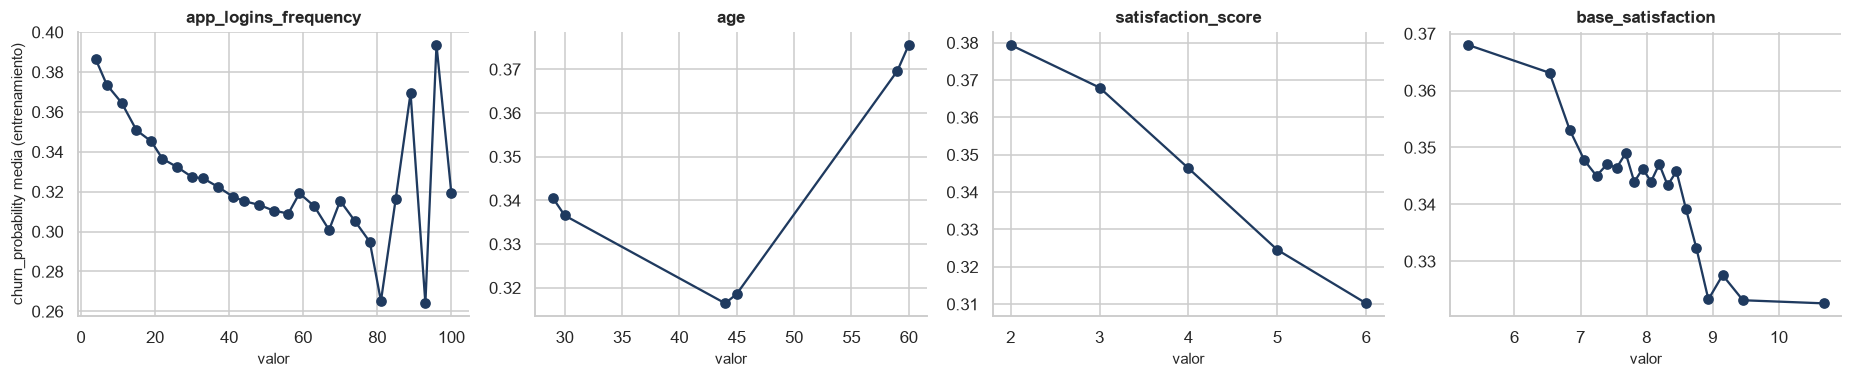


Sin `active_products`, la señal está en cuatro variables: `app_logins_frequency` (ρ = −0,279), `age` (ρ = +0,210), `satisfaction_score` (ρ = −0,190) y `base_satisfaction` (ρ = −0,164).
Las 12 variables transaccionales no aportan (|ρ| ≤ 0,018). Las curvas muestran que las
relaciones **no son lineales**: la frecuencia de uso de la aplicación reduce el riesgo con fuerza al
principio y luego se aplana, la satisfacción baja el riesgo por escalones y la satisfacción de base
lo hace en forma de S. Es la razón por la que los modelos lineales de la Entrega 2 se quedaron cortos.


In [9]:
variables = ['app_logins_frequency', 'age', 'satisfaction_score', 'base_satisfaction']
fig, ax = plt.subplots(1, 4, figsize=(17, 3.6))
for a, v in zip(ax, variables):
    x = entrenamiento[v]
    grupos = x if x.nunique() <= 30 else pd.qcut(x, 20, duplicates='drop').apply(lambda i: i.mid)
    m = objetivo.groupby(grupos).agg(['mean', 'count'])
    a.plot(m.index.astype(float), m['mean'], marker='o', color=graficos.AZUL)
    a.set_title(v)
    a.set_xlabel('valor')
ax[0].set_ylabel('churn_probability media (entrenamiento)')
plt.tight_layout()
plt.show()
display(Markdown(f"""
Sin `active_products`, la señal está en cuatro variables: {enumerar(f'`{v}` (ρ = {dec(rho[v], 3, True)})' for v in variables)}.
Las {len(derivadas)} variables transaccionales no aportan (|ρ| ≤ {dec(max_tx, 3)}). Las curvas muestran que las
relaciones **no son lineales**: la frecuencia de uso de la aplicación reduce el riesgo con fuerza al
principio y luego se aplana, la satisfacción baja el riesgo por escalones y la satisfacción de base
lo hace en forma de S. Es la razón por la que los modelos lineales de la Entrega 2 se quedaron cortos.
"""))

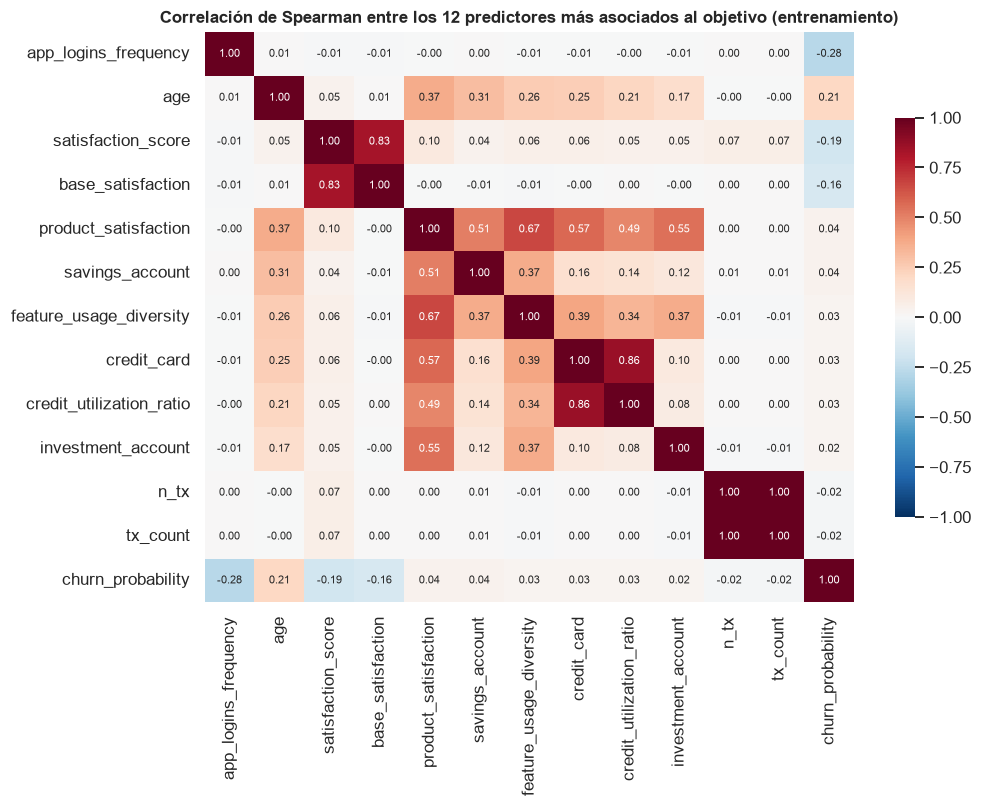


Entre las cuatro variables con señal, `satisfaction_score` y `base_satisfaction` están correlacionadas (ρ = 0,83);
el resto de los pares no supera |ρ| = 0,05. Las dos satisfacciones miden aspectos parecidos, así que la segunda aporta poco cuando el modelo ya tiene la primera (de ahí su peso pequeño en las explicaciones de la sección de interpretabilidad); la edad y la frecuencia de uso aportan información propia. Entre los demás predictores hay un duplicado: `n_tx` y `tx_count` (ρ = 1,00): `n_tx`, que se deriva del detalle de transacciones, repite `tx_count`, que ya venía en la tabla de clientes. Es una copia redundante sin efecto en los resultados (su correlación con el objetivo es de 0,018) y se mantuvo para que todas las corridas usen las mismas columnas.


In [10]:
top = list(rho.index[:12])
corr = pd.concat([X_tr[top].astype(float), p['conjuntos'].y_train_cont], axis=1).corr(method='spearman')
fig, ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(corr, cmap='RdBu_r', vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size': 7}, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title('Correlación de Spearman entre los 12 predictores más asociados al objetivo (entrenamiento)')
plt.tight_layout()
plt.show()
fuera_diag = corr.drop(index='churn_probability', columns='churn_probability').where(~np.eye(12, dtype=bool))
pares_altos = fuera_diag.abs().stack()
pares_altos = pares_altos[pares_altos > 0.9]
pares_altos = pares_altos[[a < b for a, b in pares_altos.index]]
senal = corr.loc[variables, variables].where(~np.eye(4, dtype=bool)).abs().max().max()
rho_obj = {v: abs(rho.get(v, 0)) for pair in pares_altos.index for v in pair}
frase_pares = ''
if len(pares_altos):
    frase_pares = (' Entre los demás predictores hay un duplicado: ' + enumerar(f'`{a}` y `{b}` (ρ = {dec(fuera_diag.loc[a, b], 2)})' for a, b in pares_altos.index)
                   + ': `n_tx`, que se deriva del detalle de transacciones, repite `tx_count`, que ya venía en la tabla de '
                   'clientes. Es una copia redundante sin efecto en los resultados (su correlación con el objetivo es de '
                   f'{dec(max(rho_obj.values()), 3)}) y se mantuvo para que todas las corridas usen las mismas columnas.'
                   if any('n_tx' in p for p in pares_altos.index) else
                   ' Los pares con ρ > 0,9 son ' + enumerar(f'`{a}` y `{b}`' for a, b in pares_altos.index) + '.')
c4 = corr.loc[variables, variables]
pares4 = [(a, b, c4.loc[a, b]) for i, a in enumerate(variables) for b in variables[i + 1:]]
fuertes = [(a, b, r) for a, b, r in pares4 if abs(r) >= 0.3]
debiles = max(abs(r) for a, b, r in pares4 if abs(r) < 0.3)
display(Markdown(f"""
Entre las cuatro variables con señal, {enumerar(f'`{a}` y `{b}` están correlacionadas (ρ = {dec(r, 2)})' for a, b, r in fuertes) if fuertes else 'ningún par está correlacionado'};
el resto de los pares no supera |ρ| = {dec(debiles, 2)}. {'Las dos satisfacciones miden aspectos parecidos, así que la segunda aporta poco cuando el modelo ya tiene la primera (de ahí su peso pequeño en las explicaciones de la sección de interpretabilidad); ' if any('satisfaction' in a and 'satisfaction' in b for a, b, _ in fuertes) else ''}la edad y la frecuencia de uso aportan información propia.{frase_pares}
"""))

## 6. Estructura del archivo: tres cohortes de edad

In [11]:
edades = df['age'].value_counts().sort_index()
display(edades.to_frame('clientes'))
posicion = pd.Series(np.arange(len(df)), index=df.index)
decil = pd.qcut(posicion, 10, labels=[f'{i}' for i in range(1, 11)])
por_decil = pd.DataFrame({'edad media (todos)': df['age'].groupby(decil).mean(),
                          'riesgo alto (entrenamiento)': (objetivo > umbral_p75).groupby(decil.loc[objetivo.index]).mean()})
por_decil.index.name = 'decil de posición en el archivo'
por_decil

,clientes
age,
29,8115
30,8104
44,8057
45,8082
59,8190
60,8175


,edad media (todos),riesgo alto (entrenamiento)
decil de posición en el archivo,,
1,44.5044,0.0896
2,44.4934,0.0846
3,44.5025,0.0899
4,54.8229,0.3261
5,59.4966,0.4501
6,59.4977,0.4571
7,49.6359,0.3739
8,29.4889,0.1997
9,29.5111,0.1860


In [12]:
display(Markdown(f"""
La edad toma **solo {df['age'].nunique()} valores** ({enumerar(str(e) for e in edades.index)} años), con unos
{ent(edades.mean())} clientes cada uno: el conjunto se generó por tres cohortes de edad, no a partir
de una población con edades continuas. El archivo además está **ordenado por bloques** que siguen a
esas cohortes, y el riesgo alto pasa del {pct(por_decil['riesgo alto (entrenamiento)'].min(), 0)} al
{pct(por_decil['riesgo alto (entrenamiento)'].max(), 0)} según el bloque. Esto tiene dos consecuencias. La
partición tenía que ser aleatoria (una partición por posición habría dejado cohortes enteras fuera
del entrenamiento). Y en las pruebas que dependen del orden de las filas (Ljung-Box, BDS, bootstrap
estacionario) el orden del archivo induce dependencia entre vecinos, que el bootstrap estacionario
tiene en cuenta al elegir la longitud de bloque.
"""))


La edad toma **solo 6 valores** (29, 30, 44, 45, 59 y 60 años), con unos
8.120 clientes cada uno: el conjunto se generó por tres cohortes de edad, no a partir
de una población con edades continuas. El archivo además está **ordenado por bloques** que siguen a
esas cohortes, y el riesgo alto pasa del 8 % al
46 % según el bloque. Esto tiene dos consecuencias. La
partición tenía que ser aleatoria (una partición por posición habría dejado cohortes enteras fuera
del entrenamiento). Y en las pruebas que dependen del orden de las filas (Ljung-Box, BDS, bootstrap
estacionario) el orden del archivo induce dependencia entre vecinos, que el bootstrap estacionario
tiene en cuenta al elegir la longitud de bloque.


## 7. El valor del cliente (CLV): corrección de la Entrega 1

El profesor señaló una contradicción entre dos conclusiones consecutivas de la Entrega 1. La
primera decía que el CLV **no varía** con el número de productos activos; la siguiente, que **crece de
forma ordenada** con ellos. Los datos de entrenamiento resuelven cuál es la correcta.

In [13]:
clv = entrenamiento['customer_lifetime_value']
rho_clv_ap = clv.corr(entrenamiento['active_products'], method='spearman')
clv_por_productos = clv.groupby(entrenamiento['active_products']).median()
orden_seg = ['Bronze', 'Silver', 'Gold', 'Platinum']
clv_por_segmento = clv.groupby(entrenamiento['clv_segment']).median().reindex(
    [s for s in orden_seg if s in entrenamiento['clv_segment'].unique()])
clv_por_cliente = clv.groupby(entrenamiento['customer_segment']).median().sort_values()
millones = lambda serie, nombre: (serie / 1e6).round(1).to_frame(nombre).T
display(millones(clv_por_productos, 'CLV mediano (millones de COP) por active_products'))
display(millones(clv_por_segmento, 'CLV mediano (millones de COP) por clv_segment'))
display(millones(clv_por_cliente, 'CLV mediano (millones de COP) por customer_segment'))
display(Markdown(f"""
**Conclusión corregida.** El CLV **no varía** con el número de productos activos: la correlación de
Spearman es {dec(rho_clv_ap, 4, True)} y la mediana se mantiene entre {dec(clv_por_productos.min() / 1e6, 1)} y
{dec(clv_por_productos.max() / 1e6, 1)} millones de pesos en todos los niveles. Lo que sí lo ordena es
`clv_segment` (de {dec(clv_por_segmento.iloc[0] / 1e6, 1)} a {dec(clv_por_segmento.iloc[-1] / 1e6, 1)} millones de mediana) y
`customer_segment` (de {dec(clv_por_cliente.iloc[0] / 1e6, 1)} a {dec(clv_por_cliente.iloc[-1] / 1e6, 1)} millones), y su motor es la
intensidad transaccional (ρ de Spearman = {dec(diag['rho_clv_volumen'], 3)} con el volumen total). La primera de
las dos conclusiones de la Entrega 1 era la correcta; la segunda queda corregida. La variable que
casi determina la fuga (`active_products`) no guarda relación con el valor del cliente: los dos
objetivos responden a mecanismos distintos.
"""))

active_products,1,2,3,4,5
CLV mediano (millones de COP) por active_products,128.9000,130.6000,127.9000,128.1000,134.5000


clv_segment,Bronze,Silver,Gold,Platinum
CLV mediano (millones de COP) por clv_segment,40.9000,95.7000,191.1000,492.7000


customer_segment,inactive,occasional,regular,power
CLV mediano (millones de COP) por customer_segment,31.4000,87.9000,235.9000,534.1000



**Conclusión corregida.** El CLV **no varía** con el número de productos activos: la correlación de
Spearman es −0,0013 y la mediana se mantiene entre 127,9 y
134,5 millones de pesos en todos los niveles. Lo que sí lo ordena es
`clv_segment` (de 40,9 a 492,7 millones de mediana) y
`customer_segment` (de 31,4 a 534,1 millones), y su motor es la
intensidad transaccional (ρ de Spearman = 0,984 con el volumen total). La primera de
las dos conclusiones de la Entrega 1 era la correcta; la segunda queda corregida. La variable que
casi determina la fuga (`active_products`) no guarda relación con el valor del cliente: los dos
objetivos responden a mecanismos distintos.


## 8. Observaciones del profesor y dónde se corrigen

| Entrega | Observación | Dónde se corrige |
|---|---|---|
| 1 | No había partición entrenamiento/prueba; los estadísticos del objetivo usaban todos los clientes | Sección 2 de esta página: la partición va antes de cualquier estadístico del objetivo, y `datos.diagnosticos_objetivo` lo impone en código |
| 1 | Contradicción entre dos conclusiones sobre el CLV y los productos activos | Sección 7 de esta página |
| 2 | El cuaderno se entregó sin salidas ejecutadas | Todas las páginas del libro se ejecutan de principio a fin con `libro/construir.py` y se publican con sus salidas |
| 2 | Cifras escritas a mano en las conclusiones | Toda cifra del texto se genera desde variables (`src/formato.py`) |
| 2 | Fuga en el umbral de la etiqueta (mediana del conjunto completo) | El umbral se estima solo con entrenamiento (`datos.construir_etiqueta`), aquí y en la comparación con la Entrega 2 |
| 2 | No se entrenó ninguna regresión Ridge o Lasso | La regresión es una tarea completa: 7 modelos (Ridge y Lasso incluidos) × 4 optimizadores, más la EBM |